# Import libaries

In [127]:
import kagglehub
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, average_precision_score
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import IsolationForest


# 0. Load data

In [128]:
path = kagglehub.dataset_download(
    "mlg-ulb/creditcardfraud",
    output_dir="data"
)

DATASET_DIR = Path(path)
DATA_DIR = DATASET_DIR / "creditcard.csv"

print("Path to dataset files:", DATA_DIR)

Path to dataset files: data\creditcard.csv


# 1. Data inspection

In [129]:
df = pd.read_csv(DATA_DIR)

print("Shape:", df.shape)
print("Columns:", list(df.columns))
print(df.head)

Shape: (284807, 31)
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']
<bound method NDFrame.head of             Time         V1         V2        V3        V4        V5  \
0            0.0  -1.359807  -0.072781  2.536347  1.378155 -0.338321   
1            0.0   1.191857   0.266151  0.166480  0.448154  0.060018   
2            1.0  -1.358354  -1.340163  1.773209  0.379780 -0.503198   
3            1.0  -0.966272  -0.185226  1.792993 -0.863291 -0.010309   
4            2.0  -1.158233   0.877737  1.548718  0.403034 -0.407193   
...          ...        ...        ...       ...       ...       ...   
284802  172786.0 -11.881118  10.071785 -9.834783 -2.066656 -5.364473   
284803  172787.0  -0.732789  -0.055080  2.035030 -0.738589  0.868229   
284804  172788.0   1.919565  -0.301254 -3.249640 -0.557828  2.630515   
284805

### Info
The dataset contains **284,807 observations and 31 features**. The main features are `Time` and `Amount`, while `V1`–`V28` contain anonymized numerical features obtained through **Principal Component Analysis (PCA)**. All features are numerical, making the dataset suitable for machine learning models.

# 2. Evaluate data analysis

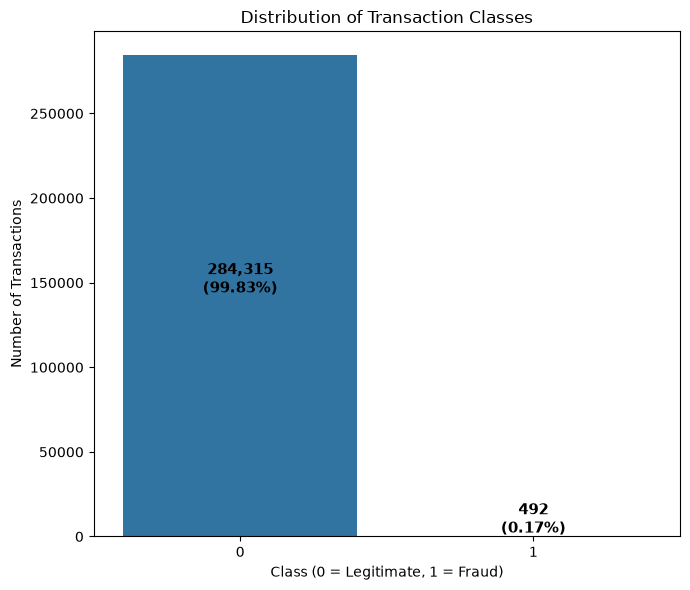

In [130]:
counts = df["Class"].value_counts()

labels = [
    f"{count:,}\n({count / len(df) * 100:.2f}%)"
    for count in counts
]

plt.figure(figsize=(7,6))
ax = sns.countplot(data=df, x="Class")

ax.bar_label(
    ax.containers[0],
    labels=labels,
    fontsize=11,
    fontweight="bold",
    label_type="center",
    padding=12
)

plt.title("Distribution of Transaction Classes")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

### Observation
The plot clearly shows the distribution of the classes in this dataset. **Fraudut transactions account for only 0.17% of all transactions**, which is obviously a good thing in a real-world scenario. However, this creates a significant **class imbalance** problem for our machine learning model.

Because of this imbalance, we will need to take a different approach to **model selection and evaluation** compared to our previous projects. Accuracy alone will not be a reliable metric, so we will focus more on metrics such as **Precision, Recall, F1-score, and PR-AUC**.

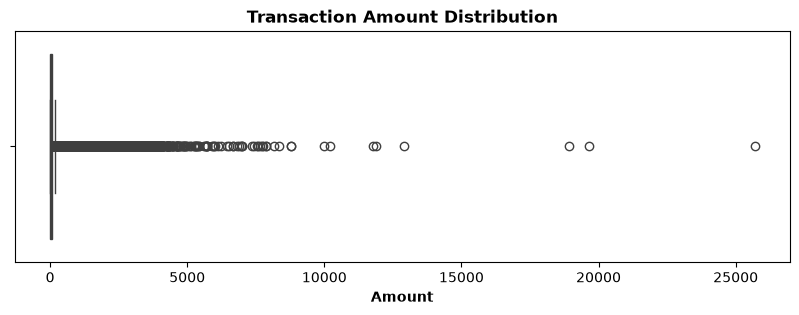

In [131]:
plt.figure(figsize=(10, 3))

sns.boxplot(
    data=df,
    x="Amount"
)

plt.title("Transaction Amount Distribution", fontweight="bold")
plt.xlabel("Amount", fontweight="bold")

plt.show()

### Observation
The plot clearly shows that most transaction amounts are concentrated near **0**. There are also some higher-value transactions reaching around **8,000**, while only a small number of transactions exceed **10,000**. This indicates a **strong right-skewed distribution with some extreme outliers**. We will consider using a **log transformation or other scaling techniques** to handle this during preprocessing.

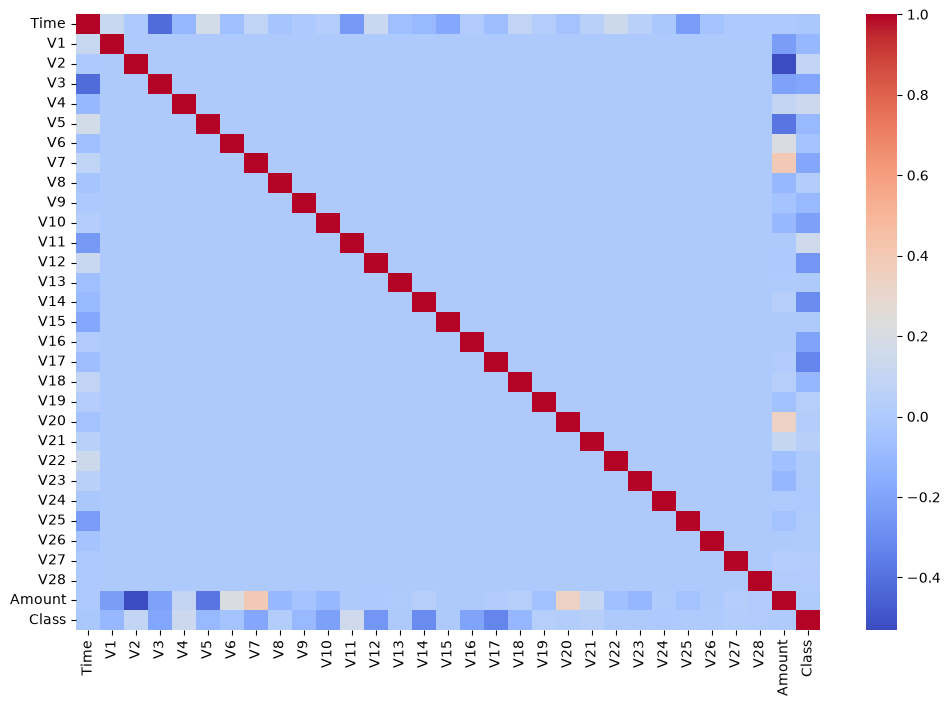

In [132]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.show()

### Observation
The correlation matrix shows that most of the **V features have very low correlation with each other**, meaning there is no strong linear relationship between them. On the other hand, **Amount and Class** show some noticeable correlations with several features, ranging from around **-0.5 to 0.5**. This suggests that some features may contain useful information for predicting fraudulent transactions.

# 3. Train/Test split

In [133]:
X = df.drop("Class", axis=1)
y = df["Class"]

print(X.shape, y.shape)

(284807, 30) (284807,)


In [134]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest class distribution:")
print(y_test.value_counts(normalize=True))

Train shape: (227845, 30)
Test shape: (56962, 30)

Train class distribution:
Class
0    0.998271
1    0.001729
Name: proportion, dtype: float64

Test class distribution:
Class
0    0.99828
1    0.00172
Name: proportion, dtype: float64


# 4. XGboost

## Create and train the model

In [135]:
# This parameter switch the model to threat the fraud transactions more important than normal transactions
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

model_xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.025,
    max_depth=5,
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
)

model_xgb.fit(
    X_train,
    y_train
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [136]:
y_pred_xgb = model_xgb.predict(X_test)
y_pred_proba = model_xgb.predict_proba(X_test)[:, 1]

print(f"Accuracy: {(accuracy_score(y_test, y_pred_xgb) * 100):.2f}%")
print(f"Precision: {(precision_score(y_test, y_pred_xgb) * 100):.2f}%")
print(f"Recall: {(recall_score(y_test, y_pred_xgb) * 100):.2f}%")
print(f"F1-score: {(f1_score(y_test, y_pred_xgb) * 100):.2f}%")

pr_auc = average_precision_score(y_test, y_pred_proba)
print(f"PR-AUC: {pr_auc:.4f}")

Accuracy: 99.52%
Precision: 24.78%
Recall: 86.73%
F1-score: 38.55%
PR-AUC: 0.7676


### Observation
As we can see, the model achieves **24.8% precision**, **86.7% recall**, and an **F1-score of 38.55%** for fraudulent transactions. The model also achieved a **PR-AUC of 0.7676**. The higher recall means that the model detects more fraudulent transactions, but the significant drop in precision indicates that it also classifies many more legitimate transactions as fraudulent.

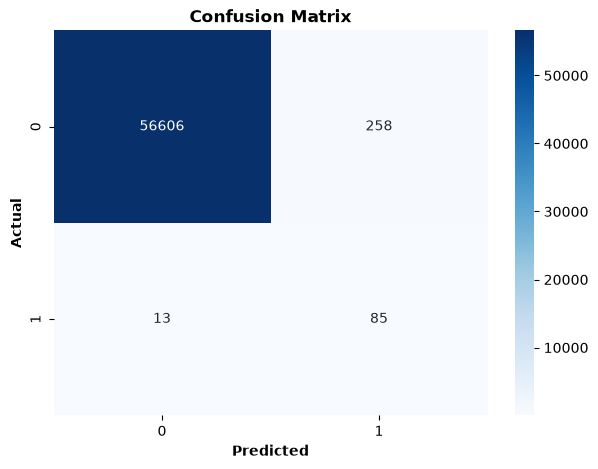

In [137]:
cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix", fontweight="bold")
plt.xlabel("Predicted", fontweight="bold")
plt.ylabel("Actual", fontweight="bold")

plt.show()

### Observation
Almost **85% of the real fraudulent transactions were correctly detected by the model**. However, the model also produced **15% false positive predictions**, meaning that 13 legitimate transactions were incorrectly classified as fraudulent.

# 5. XGBoost + SMOTE

## Create a balance dataset using SMOTE technique

In [138]:
print("-"*30)
print("Before SMOTE:\n",y_train.value_counts())
print("-"*30)

smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print()
print("-"*30)
print("After SMOTE:\n",y_train_smote.value_counts())
print("-"*30)

------------------------------
Before SMOTE:
 Class
0    227451
1       394
Name: count, dtype: int64
------------------------------

------------------------------
After SMOTE:
 Class
0    227451
1    227451
Name: count, dtype: int64
------------------------------


### Info
**SMOTE (Synthetic Minority Over-sampling Technique)** creates synthetic examples of the minority class to balance the dataset. In our case, it generates new synthetic **fraudulent transactions** to reduce the class imbalance.

## Train XGBoost on new syntetic dataset

In [139]:
model_xgb_smote = XGBClassifier(
    n_estimators=200,
    learning_rate=0.025,
    max_depth=5,
    random_state=42,
    eval_metric="logloss"
)

model_xgb_smote.fit(
    X_train_smote,
    y_train_smote
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [140]:
y_pred_smote = model_xgb_smote.predict(X_test)

y_pred_proba_smote = model_xgb_smote.predict_proba(X_test)[:, 1]

print(f"Accuracy: {(accuracy_score(y_test, y_pred_smote) * 100):.2f}%")
print(f"Precision: {(precision_score(y_test, y_pred_smote) * 100):.2f}%")
print(f"Recall: {(recall_score(y_test, y_pred_smote) * 100):.2f}%")
print(f"F1-score: {(f1_score(y_test, y_pred_smote) * 100):.2f}%")

pr_auc = average_precision_score(y_test, y_pred_proba_smote)
print(f"PR-AUC: {pr_auc:.4f}")

Accuracy: 99.37%
Precision: 20.09%
Recall: 89.80%
F1-score: 32.84%
PR-AUC: 0.7924


### Observation
The **XGBoost + SMOTE** model achieved a higher recall of almost **90%**, meaning that around **90 out of 100 fraudulent transactions were correctly detected**, while approximately 10 were missed. However, the model also achieved lower **precision** and **F1-score**, indicating that it classified more legitimate transactions as fraudulent. This means the model detects more fraud cases, but at the cost of generating more **false positive predictions**.

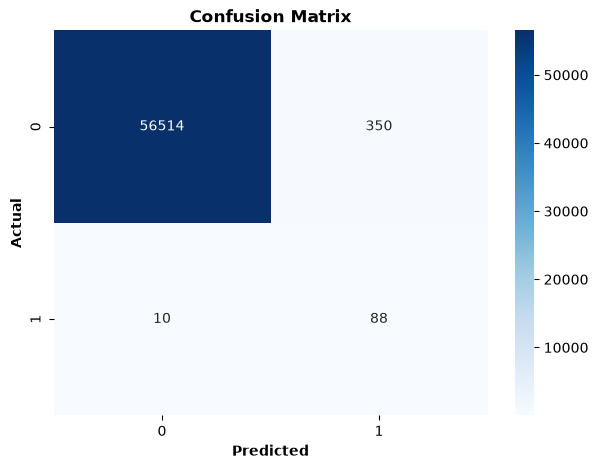

In [141]:
cm = confusion_matrix(
    y_test, y_pred_smote
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix", fontweight="bold")
plt.xlabel("Predicted", fontweight="bold")
plt.ylabel("Actual", fontweight="bold")

plt.show()

### Observation
The confusion matrix clearly shows the difference between the two models. The **XGBoost + SMOTE** model correctly detected **3 more fraudulent transactions**. However, it also classified almost **100 additional legitimate transactions as fraudulent**, resulting in a significant increase in **false positive predictions**.

# 6. Isolation Forest (unsupervised algorithm)

## Create and train the model

In [142]:
model_iso = IsolationForest(
    n_estimators=200,
    contamination="auto",
    random_state=42
)

model_iso.fit(X_train)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",None
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...ndom_state=42)


In [143]:
y_pred_iso = model_iso.predict(X_test)

y_pred_iso = (y_pred_iso == -1).astype(int)

print(f"Accuracy: {(accuracy_score(y_test, y_pred_iso) * 100):.2f}%")
print(f"Precision: {(precision_score(y_test, y_pred_iso) * 100):.2f}%")
print(f"Recall: {(recall_score(y_test, y_pred_iso) * 100):.2f}%")
print(f"F1-score: {(f1_score(y_test, y_pred_iso) * 100):.2f}%")

pr_auc = average_precision_score(y_test, y_pred_iso)
print(f"PR-AUC: {pr_auc:.4f}")

Accuracy: 96.43%
Precision: 3.91%
Recall: 83.67%
F1-score: 7.46%
PR-AUC: 0.0330


### Observation
Isolation Forest performed the worst among the tree-based models, achieving the lowest scores across most evaluation metrics. Despite changing the **hyperparameters**, the model was still unable to achieve performance comparable to XGBoost. However, it still achieved a relatively high **recall of 83.7%**, meaning that it was able to detect most of the fraudulent transactions.

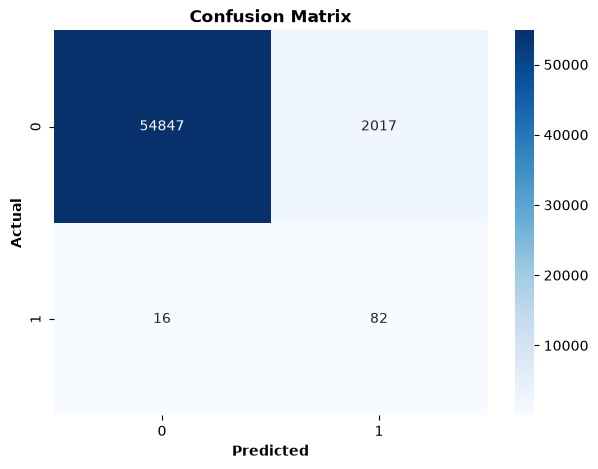

In [144]:
cm = confusion_matrix(
    y_test, y_pred_iso
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix", fontweight="bold")
plt.xlabel("Predicted", fontweight="bold")
plt.ylabel("Actual", fontweight="bold")

plt.show()

### Observation
The model performed relatively well at detecting fraudulent transactions, missing only **16 fraud cases**. However, it also generated a very large number of **false positives**, with around **2,000 legitimate transactions incorrectly classified as fraudulent**. This shows that although the model achieves good fraud detection, it produces too many false alarms.